# 03 - Sky Features

A gravitational wave comes from **somewhere**. Well, that sounds obvious, but the point is that the three detectors must agree on a single point in the sky where the wave came from. And that point imposes a rigid constraint on the detectors: H1, L1, and V1 see the same waveform, but with time delays set by the detector baselines and the source direction. A real signal has *one* consistent sky position. Pure noise has none.

This notebook builds that constraint from scratch. We construct a sky grid, compute the time delays, build a cross-detector consistency sky map, compress it into ~100 spherical harmonic coefficients, and hand those coefficients to the model via a FiLM layer. 

Prereqs: [01_data_exploration.ipynb](01_data_exploration.ipynb) for the raw data and preprocessing, [02_architecture_tour.ipynb](02_architecture_tour.ipynb) for where the sky features plug into the network, [THE_SCIENCE.md](THE_SCIENCE.md) for a more detailed physical motivation.


## 1. Setup

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data.g2net import find_dataset_dir, download_sample_dataset, load_labels, load_sample, sample_dataset_dir
from data.preprocessing import preprocess_sample, load_psd, FS, N
from sky_feasibility import (
    DETECTOR_POSITIONS, PAIRS, DET_INDEX, C_LIGHT,
    make_sky_grid, compute_time_delays, delay_to_sample_index,
    normalized_cross_correlation, evaluate_xcorr_at_delay,
    build_sky_map, compute_sh_matrix, decompose_sky_map,
)
from sky_feasibility import SkyGeometry
from models.diy_model import SkyFiLM

try:
    DATASET_DIR = find_dataset_dir()
except FileNotFoundError:
    DATASET_DIR = download_sample_dataset()
labels_df = load_labels(DATASET_DIR)

psd_candidates = [
    PROJECT_ROOT / "kaggle" / "output" / "avg_psd.npz",
    PROJECT_ROOT / "avg_psd.npz",
    sample_dataset_dir(PROJECT_ROOT) / "avg_psd.npz",
]
psd_path = next((p for p in psd_candidates if p.exists()), None)
avg_psd = load_psd(psd_path)
print(f"Dataset: {DATASET_DIR}")
print(f"PSD:     {psd_path.name}")
print(f"Samples: {len(labels_df):,}")


Dataset: D:\Programming\g2net-gravitational-wave-detection
PSD:     avg_psd.npz
Samples: 560,000


## 2. A Grid on the Sphere

We need to evaluate consistency at a bunch of candidate sky positions. Pick ~192 points roughly uniformly distributed on $S^2$, parameterized by colatitude `theta` in `[0, pi]` and azimuth `phi` in `[0, 2*pi)`. The grid is uniform in `cos(theta)` so each latitude band covers equal area, i.e. there's no clumping at the poles.


Sky pixels: 200
theta range: [0.00, 3.14]  (0 = north pole, pi = south pole)
phi range:   [0.00, 5.97)   (azimuth)


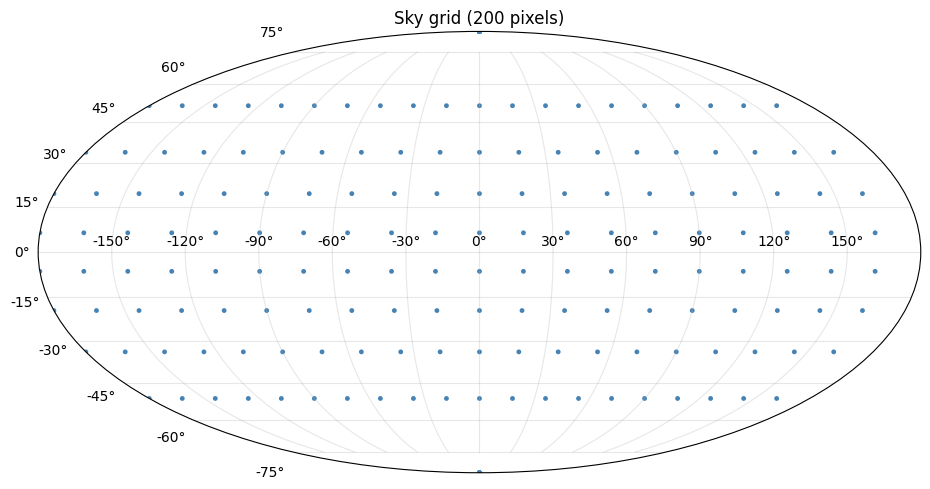

In [13]:
theta, phi = make_sky_grid(n_pix=192)
print(f"Sky pixels: {len(theta)}")
print(f"theta range: [{theta.min():.2f}, {theta.max():.2f}]  (0 = north pole, pi = south pole)")
print(f"phi range:   [{phi.min():.2f}, {phi.max():.2f})   (azimuth)")

# Mollweide projection: convert to (lat, lon)
lat = np.pi / 2 - theta
lon = phi - np.pi

fig, ax = plt.subplots(subplot_kw={"projection": "mollweide"}, figsize=(10, 5))
ax.scatter(lon, lat, c="steelblue", s=12, edgecolors="none")
ax.set_title(f"Sky grid ({len(theta)} pixels)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Time Delays from Geometry

Each detector sits at a fixed position on Earth (give or take continental drift). A plane-wave signal from direction $\hat{n}$ arrives at detector `i` before detector `j` if detector `i` is closer along that direction:
$$
\tau_{ij} = \frac{-(r_i - r_j)}{c} \cdot  \hat{n}
$$
For every sky pixel, compute the delay for each pair. Max delay is ~10 ms between H1-L1 (3000 km apart) and ~27 ms between LIGO and Virgo (8000+ km). Let's plot all three pairs.


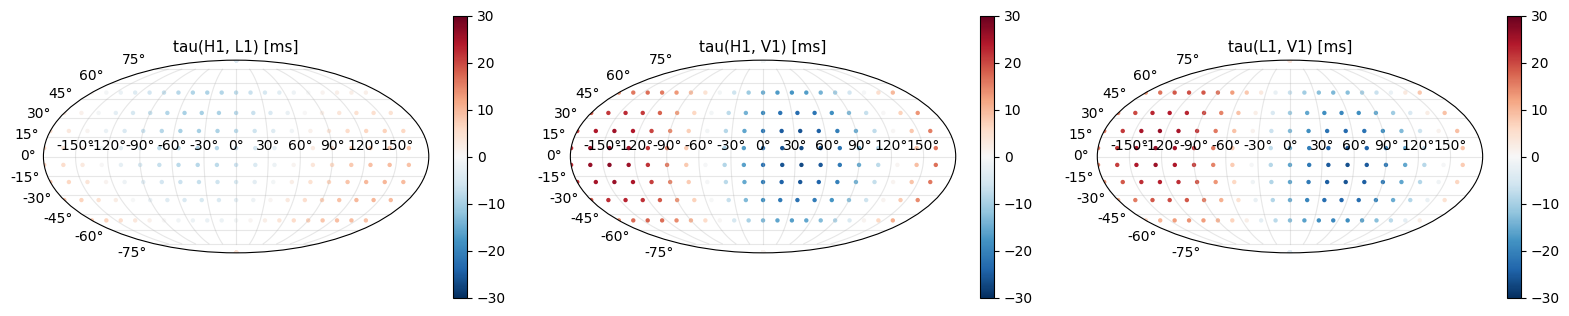

  tau(H1-L1):  min= -9.94 ms,  max= +9.94 ms
  tau(H1-V1):  min=-27.19 ms,  max=+27.19 ms
  tau(L1-V1):  min=-26.43 ms,  max=+26.43 ms


In [3]:
delays = compute_time_delays(theta, phi)

fig, axes = plt.subplots(1, 3, subplot_kw={"projection": "mollweide"}, figsize=(16, 5))
for ax, (i, j) in zip(axes, PAIRS):
    d_ms = delays[(i, j)] * 1000  # to ms
    sc = ax.scatter(lon, lat, c=d_ms, cmap="RdBu_r", s=10, edgecolors="none",
                    vmin=-30, vmax=30)
    ax.set_title(f"tau({i}, {j}) [ms]", fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

for pair in PAIRS:
    d = delays[pair] * 1000
    print(f"  tau({pair[0]}-{pair[1]}):  min={d.min():+6.2f} ms,  max={d.max():+6.2f} ms")


Hanford-Livingston has the shortest baseline (both in the US), so the smallest range. Anything involving Virgo covers a wider spread. These delay maps are what the sky map looks up.


## 4. Build a Sky Map

The recipe:

1. Preprocess the sample (bandpass + whiten + window + normalize - same thing the model trains on).
2. For each detector pair, compute the full normalized cross-correlation $\rho_{ij}(\tau)$ across all lags.
3. For each sky pixel `k`, look up $\rho_{ij}$ at the geometric delay $\tau_{ij}(k)$.
4. Sum the squared values across pairs: $C(k) = \sum_{ij} \rho_{ij} \left( \tau_{ij}(k) \right)^2$.

A real signal from direction $\hat{n}$ should produce a bright spot near $\hat{n}$. Pure noise should give a diffuse, low-value map. Let's test.


In [4]:
signal_row = labels_df[labels_df["target"] == 1].iloc[0]
noise_row  = labels_df[labels_df["target"] == 0].iloc[0]

raw_signal = load_sample(signal_row["id"], dataset_dir=DATASET_DIR)
raw_noise  = load_sample(noise_row["id"],  dataset_dir=DATASET_DIR)

proc_signal = preprocess_sample(raw_signal, avg_psd)
proc_noise  = preprocess_sample(raw_noise,  avg_psd)

delay_indices = {pair: delay_to_sample_index(d) for pair, d in delays.items()}

sky_signal = build_sky_map(proc_signal, delay_indices)
sky_noise  = build_sky_map(proc_noise,  delay_indices)

print(f"sky map signal: shape={sky_signal.shape}  min={sky_signal.min():.3f}  max={sky_signal.max():.3f}  mean={sky_signal.mean():.3f}")
print(f"sky map noise:  shape={sky_noise.shape}  min={sky_noise.min():.3f}  max={sky_noise.max():.3f}  mean={sky_noise.mean():.3f}")


sky map signal: shape=(200,)  min=0.000  max=0.009  mean=0.002
sky map noise:  shape=(200,)  min=0.000  max=0.007  mean=0.002


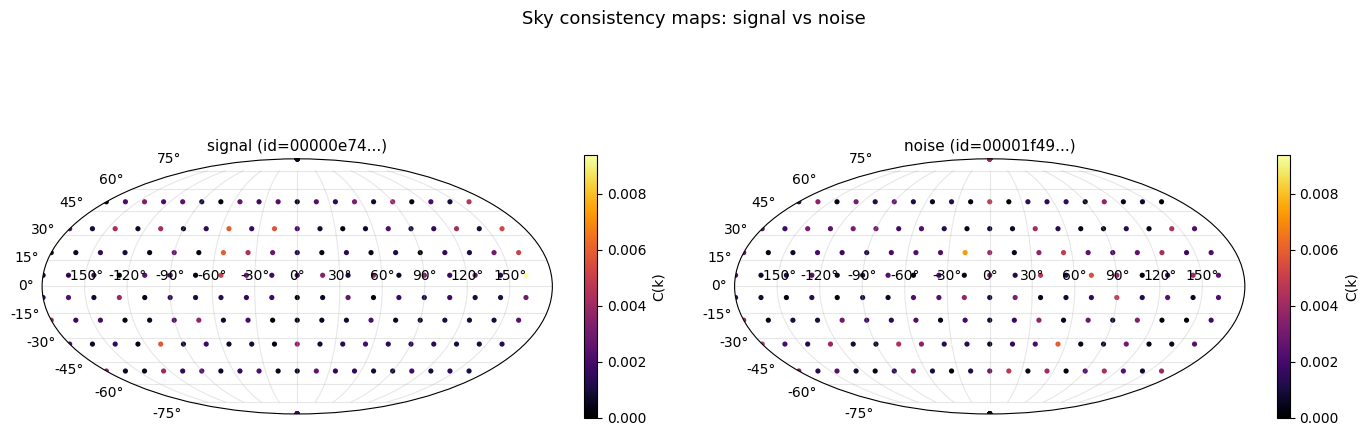

In [5]:
fig, axes = plt.subplots(1, 2, subplot_kw={"projection": "mollweide"}, figsize=(14, 5))
vmax = max(sky_signal.max(), sky_noise.max())
vmin = 0

for ax, sm, title in zip(axes, [sky_signal, sky_noise], ["signal", "noise"]):
    sc = ax.scatter(lon, lat, c=sm, cmap="inferno", s=14, edgecolors="none",
                    vmin=vmin, vmax=vmax)
    ax.set_title(f"{title} (id={signal_row['id'][:8] if title=='signal' else noise_row['id'][:8]}...)", fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax, shrink=0.6, label="C(k)")
fig.suptitle("Sky consistency maps: signal vs noise", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Individual samples are noisy. At low SNR you might not see a clean hot spot. The discriminative signal is statistical: averaged across many samples, signal maps have more structure than noise maps, and that structure lives in a small set of spherical harmonic modes.

Let's make that concrete by averaging a handful.


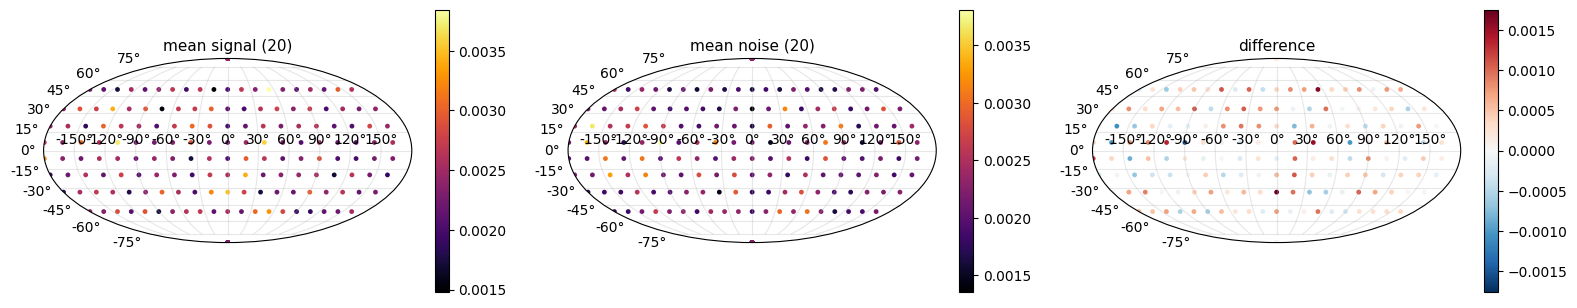

In [6]:
n_avg = 20

sig_rows = labels_df[labels_df["target"] == 1].sample(n_avg, random_state=1)
noi_rows = labels_df[labels_df["target"] == 0].sample(n_avg, random_state=1)

def mean_sky_map(rows):
    maps = []
    for _, r in rows.iterrows():
        raw = load_sample(r["id"], dataset_dir=DATASET_DIR)
        proc = preprocess_sample(raw, avg_psd)
        maps.append(build_sky_map(proc, delay_indices))
    return np.mean(maps, axis=0)

mean_sig = mean_sky_map(sig_rows)
mean_noi = mean_sky_map(noi_rows)
diff = mean_sig - mean_noi

fig, axes = plt.subplots(1, 3, subplot_kw={"projection": "mollweide"}, figsize=(16, 5))
for ax, sm, title in zip(axes, [mean_sig, mean_noi, diff],
                         [f"mean signal ({n_avg})", f"mean noise ({n_avg})", "difference"]):
    cmap = "RdBu_r" if title == "difference" else "inferno"
    lim = np.max(np.abs(diff)) if title == "difference" else None
    kwargs = dict(vmin=-lim, vmax=lim) if lim else {}
    sc = ax.scatter(lon, lat, c=sm, cmap=cmap, s=12, edgecolors="none", **kwargs)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()


The mean signal map is brighter overall and has visible structure. The mean noise map is flatter. The difference is where the model gets its edge.


## 5. Compressing the Sky Map: Spherical Harmonics

A 192-pixel sky map is too big and too noisy to feed directly into a neural network. Compress it into spherical harmonic coefficients instead. SHs are the Fourier basis on the sphere: $Y_l^m(\theta, \phi)$ for degree `l` and order `m`. Low degrees capture broad structure (monopole, dipole, quadrupole...), high degrees capture fine detail.

With $l_{max} = 10$, that's $(l_{max} + 1)^2 = 121$ coefficients. The production model uses exactly this.


SH design matrix: (200, 121)  (121 = (l_max+1)^2 coefs)


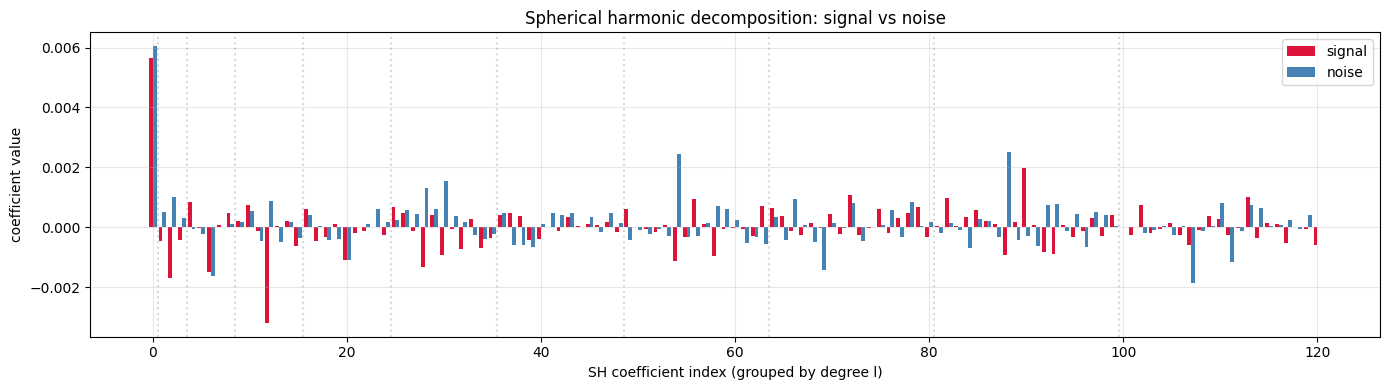

In [7]:
l_max = 10
sh_matrix = compute_sh_matrix(theta, phi, l_max)
print(f"SH design matrix: {sh_matrix.shape}  ({sh_matrix.shape[1]} = (l_max+1)^2 coefs)")

coefs_signal = decompose_sky_map(sky_signal, sh_matrix)
coefs_noise  = decompose_sky_map(sky_noise,  sh_matrix)

fig, ax = plt.subplots(figsize=(14, 4))
idx = np.arange(len(coefs_signal))
ax.bar(idx - 0.2, coefs_signal, width=0.4, label="signal", color="crimson")
ax.bar(idx + 0.2, coefs_noise,  width=0.4, label="noise",  color="steelblue")
# shade degree boundaries
for l in range(1, l_max + 1):
    ax.axvline(l**2 - 0.5, color="gray", alpha=0.3, linestyle=":")
ax.set_xlabel("SH coefficient index (grouped by degree l)")
ax.set_ylabel("coefficient value")
ax.set_title("Spherical harmonic decomposition: signal vs noise")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The $l=0$ monopole (leftmost bar) reliably separates signal from noise. It's the mean of the sky map, and signal maps tend to be brighter. In the feasibility test, the monopole alone reached AUC ~0.60 as a univariate classifier. Higher-order coefficients carry weaker but independent information.


## 6. The Fast Path: SkyGeometry

`build_sky_map + decompose_sky_map` works for exploration, but the least-squares solve is wasteful per sample. The `SkyGeometry` class precomputes the delay indices and the SH **pseudo-inverse**, reducing decomposition to one matrix-vector multiply. Total time per sample drops to ~1 ms (dominated by the three cross-correlations, not the SH projection).


In [8]:
sky_geo = SkyGeometry(n_pix=192, l_max=10)
print(f"n_coeffs: {sky_geo.n_coeffs}")

import time
sh_fast = sky_geo.extract(proc_signal)
t0 = time.perf_counter()
for _ in range(500):
    sky_geo.extract(proc_signal)
dt_ms = (time.perf_counter() - t0) / 500 * 1000
print(f"Per-sample extraction time: {dt_ms:.3f} ms")
print(f"Match slow path? {np.allclose(sh_fast, coefs_signal, atol=1e-5)}")


n_coeffs: 121
Per-sample extraction time: 1.738 ms
Match slow path? True


Fast enough to precompute for all ~600k training samples in a few minutes, or to compute on-the-fly from the DataLoader without bottlenecking training. In practice we precompute into the same `.pt` shards as the signals (`create_tensors.py --add-sky --l-max 10`).


## 7. How the Sky Features Enter the Model: FiLM

The first sky run concatenated the 121 coefficients onto the 512-dim CNN feature vector and let a linear layer sort it out. AUC landed at 0.873, within noise of the no-sky baseline at 0.874. Why?

**Dimensional imbalance.** 121 coefficients next to 512 CNN features get swallowed by the first linear layer of the classifier. The classifier has every incentive to route signal through the wider, better-trained pathway and ignore the SH side.

**FiLM** (Feature-wise Linear Modulation) fixes this by giving the sky features a *multiplicative* influence on every CNN channel. The SH coefficients pass through a BatchNorm + 2-layer MLP that emits a per-channel `(gamma, beta)`. The pooled features become:

`features = (1 + gamma) * features + beta`

Both `gamma` and `beta` are **tanh-bounded**, so `(1 + gamma) in (0, 2)` - no sign flips, no runaway amplification. The output projection of the MLP is zero-initialized, so at step 0 `gamma = 0`, `beta = 0`, and the module is the identity. The optimizer has to *earn* any use of the FiLM path. Baseline performance is recovered exactly.


In [9]:
feat_dim = 512  # 32 * n_channels with n=16
n_sky_features = 121
film = SkyFiLM(n_sky_features=n_sky_features, feat_dim=feat_dim, hidden_dim=128)
film.reset_to_identity()  # match model init
film.eval()

pooled = torch.randn(4, feat_dim)
sky_t = torch.randn(4, n_sky_features)

with torch.no_grad():
    out = film(pooled, sky_t)

print(f"pooled: {tuple(pooled.shape)}")
print(f"sky:    {tuple(sky_t.shape)}")
print(f"out:    {tuple(out.shape)}")
# At init, gamma=0 and beta=0, so output should equal input
print(f"Identity at init? {torch.allclose(out, pooled, atol=1e-6)}")

# inspect what gamma and beta look like right after init
with torch.no_grad():
    gb = film.fc2(film.act(film.fc1(film.bn(sky_t))))
    gamma, beta = gb.chunk(2, dim=1)
print(f"gamma range: [{gamma.min().item():.3f}, {gamma.max().item():.3f}]  (tanh applied: all zero before training)")
print(f"beta range:  [{beta.min().item():.3f}, {beta.max().item():.3f}]")


pooled: (4, 512)
sky:    (4, 121)
out:    (4, 512)
Identity at init? True
gamma range: [0.000, 0.000]  (tanh applied: all zero before training)
beta range:  [0.000, 0.000]


Identity at init means step 0 of training is exactly the baseline model. If FiLM learns to do something useful, training loss goes down. If it doesn't, `gamma` and `beta` stay near zero and the module is a no-op. No way to make it worse - only upside.


## 8. Augmentation Compatibility

Sky features encode **cross-detector coherence**: relative amplitudes, phases, and time offsets between H1, L1, and V1. Any augmentation that breaks those relationships poisons the sky features.

| Augmentation | Sky-compatible? | Reason |
|---|---|---|
| Gaussian noise | yes | degrades SNR uniformly, preserves timing/phase |
| Channel shuffle | yes | H1/L1 swap, sky map is Z2-invariant |
| Amplitude scaling | yes | uniform scaling, preserves timing/phase |
| Dropout / stochastic depth | yes | acts on network, not input signals |
| Weight decay | yes | acts on parameters |
| Label smoothing | yes | acts on targets |
| SWA | yes | parameter averaging, no interaction with inputs |
| Manifold mixup (post-pool) | yes | mixes pooled features, time domain untouched |
| **Spectral dropout** | **no** | destroys inter-detector phase coherence |
| **Time shift** | **no** | breaks precomputed sky geometry (delay model) |
| **Input-space mixup** | **no** | two physical sources get mixed, SH coefs become meaningless |

The current training config turns off time shift, spectral dropout, and input mixup. **Manifold mixup** (mixing features post-pool instead of pre-conv) replaces input mixup as the main regularizer without corrupting sky coherence. The SH side of manifold mixup keeps the dominant sample's sky coefs when `lam >= 0.5` - no interpolation between two physical sky positions.


## 9. Explore

Pick your own samples and stare at sky maps.


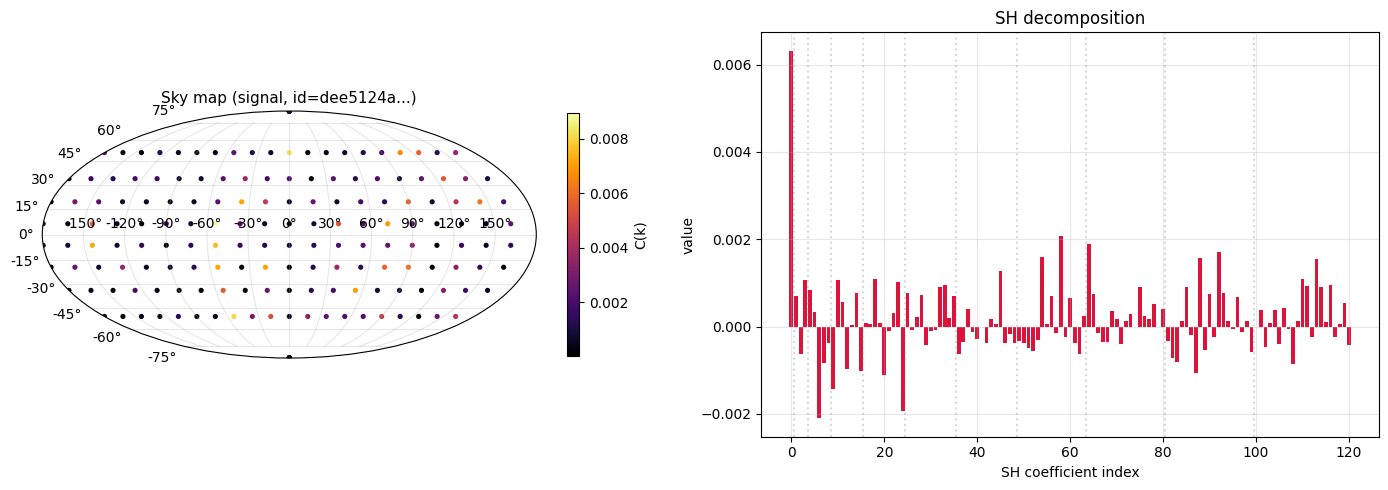

In [10]:
def explore_sky_map(sample_id: str, label: int):
    raw = load_sample(sample_id, dataset_dir=DATASET_DIR)
    proc = preprocess_sample(raw, avg_psd)
    sm = build_sky_map(proc, delay_indices)
    coefs = sky_geo.extract(proc)

    fig = plt.figure(figsize=(14, 5))
    ax_map = fig.add_subplot(1, 2, 1, projection="mollweide")
    sc = ax_map.scatter(lon, lat, c=sm, cmap="inferno", s=14, edgecolors="none")
    ax_map.set_title(f"Sky map ({'signal' if label else 'noise'}, id={sample_id[:8]}...)", fontsize=11)
    ax_map.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax_map, shrink=0.6, label="C(k)")

    ax_sh = fig.add_subplot(1, 2, 2)
    color = "crimson" if label else "steelblue"
    ax_sh.bar(np.arange(len(coefs)), coefs, color=color)
    for l in range(1, 11):
        ax_sh.axvline(l**2 - 0.5, color="gray", alpha=0.3, linestyle=":")
    ax_sh.set_xlabel("SH coefficient index")
    ax_sh.set_ylabel("value")
    ax_sh.set_title("SH decomposition")
    ax_sh.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


row = labels_df.sample(1).iloc[0]
explore_sky_map(row["id"], int(row["target"]))


Re-run the cell to see a different sample. At very low SNR, signal and noise sky maps will look nearly identical to your eye. That's exactly the point. The information is there, but it's statistical, distributed across many SH modes and many samples. The network's job is to extract it.


## Up Next

The model knows how to chew on signals, and now you know where those 121 mysterious numbers come from. In [04_results_and_errors.ipynb](04_results_and_errors.ipynb) we finally put a trained model on the val set and find out what it's actually good at, and what still trips it up.
